# 🐾 Diet Patterns, Food Safety, and Chronic Disease Risk in Domestic Dogs
### ICS604 – Applied Data Science | Final Project
**Author:** Maritza Medina  
**Date:** Spring 2026  
**Dataset:** Knight et al. (2022) PLOS ONE – *Vegan versus meat-based dog food: Guardian-reported indicators of health*  
**Data Repository:** [OSF – https://osf.io/nbepu](https://osf.io/nbepu)

---

## Project Overview

Nutrition is one of the most debated influences on long-term canine health. Dog owners increasingly choose among commercial kibble, canned diets, raw feeding, and home-cooked meals, often with limited evidence about how those choices relate to chronic disease outcomes. This project uses a large, open-access survey dataset to examine whether diet type is associated with chronic disease prevalence in dogs, and which factors most strongly predict disease risk.

### Research Questions

| # | Research Question | Type | Priority |
|---|---|---|---|
| RQ1 | Is there a statistically significant **unadjusted** association between diet type and the prevalence of selected chronic diseases? | Descriptive / Inferential | Primary |
| RQ2 | Do dogs fed home-made/raw diets differ from dogs fed commercial diets in the prevalence of cancer and other chronic conditions? | Comparative | Primary |
| RQ3 | After controlling for demographic and lifestyle factors, does diet type predict the **adjusted** odds of a dog having cancer? | Inferential (Adjusted) | Primary |
| RQ4 | What variables are the **strongest predictors** of chronic disease risk in dogs? | Predictive | Primary |
| RQ5 | What do FDA pet food recall trends reveal about contamination risks? | Exploratory / Descriptive | Secondary |

> **Note on RQ1 vs. RQ3 (Professor Feedback):** RQ1 provides an *unadjusted* picture across multiple diseases — it establishes whether raw patterns exist in the data before any controls are applied. RQ3 then *narrows the focus to cancer specifically* and applies a full logistic regression model with demographic and lifestyle covariates. This progression from unadjusted to adjusted is intentional: RQ1 motivates the question, and RQ3 answers it rigorously.

---


In [3]:
# Mount Google Drive so Colab can access files saved in your Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## Step 0: Install and Import Libraries

Before any analysis, we install and import all required Python libraries. We use:
- **pandas** and **numpy** for data manipulation
- **matplotlib** and **seaborn** for visualization
- **scipy.stats** for chi-square and proportion tests
- **statsmodels** for logistic regression with odds ratios
- **scikit-learn** for machine learning (Random Forest, Decision Tree)
- **warnings** to suppress non-critical messages

Run this cell first every time you open the notebook.


In [4]:
# ── Install any packages not available in the default Colab environment ──────

# ── Standard library imports ─────────────────────────────────────────────────
import os
import urllib.request
import warnings
warnings.filterwarnings('ignore')  # Suppress convergence and deprecation warnings

# ── Data manipulation ─────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Statistical testing ───────────────────────────────────────────────────────
import scipy.stats as stats

# ── Regression modeling ───────────────────────────────────────────────────────
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ── Machine learning ──────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

# ── Global plot settings ──────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12
})

print("✅ All libraries imported successfully.")


✅ All libraries imported successfully.


---
## Step 1: Data Loading

### About the Dataset

We use the open-access dataset from:

> Knight A, Huang E, Rai N, Brown H (2022) *Vegan versus meat-based dog food: Guardian-reported indicators of health.* PLOS ONE 17(4): e0265662. https://doi.org/10.1371/journal.pone.0265662

The dataset was collected via an online survey of 2,639 dog owners. Each owner reported on one dog that had been on the same diet for at least one year. It includes:
- **Dog demographics:** breed size, age, sex/neuter status, activity level
- **Diet type:** conventional meat-based, raw meat-based, or vegan
- **Health indicators:** 22 specific health conditions (cancer, heart disease, allergies, etc.)
- **Healthcare use:** veterinary visits, medication use, therapeutic diet status

The data file (`Canine health results.xlsx`) is hosted publicly on the OSF repository at [https://osf.io/nbepu](https://osf.io/nbepu) and will be downloaded automatically below.


In [5]:
# ── Define the download URL and local file path ───────────────────────────────
# This is the direct download link for the canine health Excel file from OSF
OSF_URL = "https://osf.io/download/nj6fp/"
FILE_PATH = "canine_health_results.xlsx"

# ── Download the file only if it doesn't already exist ───────────────────────
# This avoids re-downloading on repeated runs
if not os.path.exists(FILE_PATH):
    print("Downloading dataset from OSF repository...")
    urllib.request.urlretrieve(OSF_URL, FILE_PATH)
    print(f"  ✅ Saved to: {FILE_PATH}")
else:
    print(f"  ℹ️  Dataset already present at: {FILE_PATH}")

# ── Load the 'All' sheet from the Excel workbook ─────────────────────────────
# The workbook has two sheets: 'Summary' (metadata) and 'All' (raw data)
df_raw = pd.read_excel(FILE_PATH, sheet_name='All')

print(f"\n📊 Dataset loaded: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
print("\nFirst 3 rows (raw column names):")
display(df_raw.head(3))


  ✅ Saved to: canine_health_results.xlsx

📊 Dataset loaded: 2536 rows × 35 columns

First 3 rows (raw column names):


,Unique Response Number,11.a. Breed size,12. How old is your animal in years? (Best estimate),13. Sex and neuter status,14. Is your animal:,15. Is your animal on a therapeutic or prescription (i.e. medical) diet?,16. How many times has your animal visited a veterinarian (or received a vet home visit) in the previous 12 months?,"16.a. Think about your veterinarian. Which of the following would most likely describe their opinions about your animal’s medical condition over the previous 12 months? (Please give your main veterinarian's opinion, if this differs from your own, or from",16.a.i. Health status other 161 with substitutions,"17. Has your animal received medications in the last year, apart from routine vaccinations and treatments for skin or internal parasites, such as fleas, ticks, lice, heartworm and intestinal worms? Please do not include neutering operations (spay/castrati",...,Internal parasites,Kidney,Liver,Lower urinary tract,Mobility,Other medical,Other musculoskeletal (muscle or bone) disease,Respiratory tract (airways/lungs),Skin/coat,No. disorders per unwell dog
0,587958-587949-58298356,Medium (11.4–22.3 kg or 25–49 lb),7,"Male, sexually intact",None of the above,No,3,Minor or infrequent problems,"Gastrointestinal (e.g. diarrhoea, vomiting)",Yes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1,587958-587949-58300907,Giant (> 40.9 kg or > 90 lb),10,"Male, castrated",None of the above,No,2,Significant or frequent problems,Mobility,Yes,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0
2,587958-587949-58308903,Medium (11.4–22.3 kg or 25–49 lb),6,"Female, spayed",None of the above,No,3,Minor or infrequent problems,Mobility,Yes,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0


---
## Step 2: Data Cleaning and Preprocessing

The raw dataset has very long survey-question column headers and categorical responses that need to be standardized. This step covers:

1. **Renaming columns** to short, analysis-friendly names
2. **Converting disease columns** from presence/absence (1 / NaN) to binary integers (1 / 0)
3. **Cleaning the Age variable** (stored as a string in the survey)
4. **Categorizing Diet** into a simplified three-group variable and a binary commercial vs. non-commercial variable
5. **Creating composite outcome variables** for RQ4
6. **Handling missing values** using a transparent, documented strategy

> **Preprocessing Philosophy:** We follow the proposal's guidance to document every operational definition and collapse ambiguous categories only where justified. Missing values in key variables (age, diet) result in row exclusion; moderate missingness in secondary variables is handled by complete-case analysis within each model.


In [6]:
# ── Step 2a: Rename columns ───────────────────────────────────────────────────
# Map the full survey question text to short, descriptive variable names
column_mapping = {
    'Unique Response Number':
        'id',
    '11.a. Breed size':
        'breed_size',
    '12. How old is your animal in years? (Best estimate)':
        'age_str',
    '13. Sex and neuter status':
        'sex_neuter',
    '14. Is your animal:':
        'activity_level',
    '15. Is your animal on a therapeutic or prescription (i.e. medical) diet?':
        'therapeutic_diet',
    '16. How many times has your animal visited a veterinarian (or received a vet home visit) in the previous 12 months?':
        'vet_visits_str',
    '17. Has your animal received medications in the last year, apart from routine vaccinations and treatments for skin or internal parasites, such as fleas, ticks, lice, heartworm and intestinal worms? Please do not include neutering operations (spay/castrati':
        'medication',
    '18. In your own opinion, which best describes your animal over the previous 12 months:':
        'owner_health_opinion',
    '29. Diet':
        'diet_type',
    # ── Disease columns (1 = condition present, NaN = absent) ─────────────────
    'Allergy':                                      'cond_allergy',
    'Anal glands':                                  'cond_anal_glands',
    'Body weight':                                  'cond_obesity',
    'Cancer/tumours':                               'cond_cancer',
    'Dental/oral (teeth/mouth)':                    'cond_dental',
    'Ears':                                         'cond_ears',
    'Epilepsy':                                     'cond_epilepsy',
    'Eyes':                                         'cond_eyes',
    'Gastrointestinal (e.g. diarrhoea, vomiting)':  'cond_gi',
    'Heart':                                        'cond_heart',
    # NOTE: The Hormonal column in the Excel file uses Unicode curly apostrophes
    # (U+2019) which are hard to reproduce in source code. We use just the first
    # 32 characters as the key; the build_rename_map() helper below will match
    # it via a 30-char prefix comparison.
    'Hormonal (e.g. diabetes, hyper-/':             'cond_hormonal',
    'Injury':                                       'cond_injury',
    'Internal parasites':                           'cond_parasites',
    'Kidney':                                       'cond_kidney',
    'Liver':                                        'cond_liver',
    'Lower urinary tract':                          'cond_urinary',
    # NOTE: 'Mobility' had a trailing space in earlier versions — removed here.
    'Mobility':                                     'cond_mobility',
    'Other medical':                                'cond_other',
    'Other musculoskeletal (muscle or bone) disease': 'cond_musculo',
    'Respiratory tract (airways/lungs)':            'cond_respiratory',
    'Skin/coat':                                    'cond_skin',
    'No. disorders per unwell dog':                 'n_disorders'
}

# ── Robust rename: falls back to 30-char prefix match ────────────────────────
# Some column names in the Excel file contain Unicode curly apostrophes (U+2019)
# or trailing spaces that are difficult to reproduce exactly in Python source.
# This helper tries an exact match first; if that fails it compares the first
# 30 characters (lowercased, stripped) so those tricky columns are still caught.
def build_rename_map(df_cols, mapping):
    rename_map = {}
    for key, new_name in mapping.items():
        if key in df_cols:
            rename_map[key] = new_name
        else:
            key_short = key[:30].lower().strip()
            for col in df_cols:
                if col[:30].lower().strip() == key_short:
                    rename_map[col] = new_name
                    break
    return rename_map

rename_map = build_rename_map(df_raw.columns.tolist(), column_mapping)
df = df_raw.rename(columns=rename_map).copy()

# Verify every expected column was successfully renamed
missing = [c for c in column_mapping.values() if c not in df.columns]
if missing:
    print(f"⚠️  Could not rename: {missing}")
else:
    print("✅ All columns renamed successfully.")
print("Available columns:", df.columns.tolist())


✅ All columns renamed successfully.
Available columns: ['id', 'breed_size', 'age_str', 'sex_neuter', 'activity_level', 'therapeutic_diet', 'vet_visits_str', "16.a. Think about your veterinarian. Which of the following would most likely describe their opinions about your animal’s medical condition over the previous 12 months? (Please give your main veterinarian's opinion, if this differs from your own, or from ", '16.a.i. Health status other 161 with substitutions', 'medication', 'owner_health_opinion', 'diet_type', 'cond_allergy', 'cond_anal_glands', 'Behavioural', 'cond_obesity', 'cond_cancer', 'cond_dental', 'cond_ears', 'cond_epilepsy', 'cond_eyes', 'cond_gi', 'cond_heart', 'cond_hormonal', 'cond_injury', 'cond_parasites', 'cond_kidney', 'cond_liver', 'cond_urinary', 'cond_mobility', 'cond_other', 'cond_musculo', 'cond_respiratory', 'cond_skin', 'n_disorders']


In [7]:
# ── Step 2b: Define disease columns list ─────────────────────────────────────
# These are the binary condition indicators we will use throughout the analysis
DISEASE_COLS = [
    'cond_cancer', 'cond_heart', 'cond_allergy', 'cond_obesity',
    'cond_gi', 'cond_mobility', 'cond_skin', 'cond_dental',
    'cond_kidney', 'cond_hormonal'
]

# ── Convert disease columns from 1/NaN to 1/0 ────────────────────────────────
# In the raw data, a '1' means the condition was reported; NaN means it was not.
# We fill NaN with 0 to create proper binary indicators.
for col in DISEASE_COLS:
    if col in df.columns:
        df[col] = df[col].fillna(0).astype(int)

print("✅ Disease indicators converted to binary (0/1).")
print("\nDisease column prevalence (% of all dogs):")
prev_df = (df[DISEASE_COLS].mean() * 100).round(2).reset_index()
prev_df.columns = ['Condition', 'Prevalence (%)']
display(prev_df)


✅ Disease indicators converted to binary (0/1).

Disease column prevalence (% of all dogs):


,Condition,Prevalence (%)
0,cond_cancer,1.97
1,cond_heart,1.77
2,cond_allergy,0.79
3,cond_obesity,3.15
4,cond_gi,7.06
5,cond_mobility,5.32
6,cond_skin,5.80
7,cond_dental,4.34
8,cond_kidney,0.67
9,cond_hormonal,1.22


Age variable summary:
count    2534.000000
mean        6.182320
std         3.647072
min         1.000000
25%         3.000000
50%         6.000000
75%         9.000000
max        20.000000
Name: age, dtype: float64

Missing age values: 2


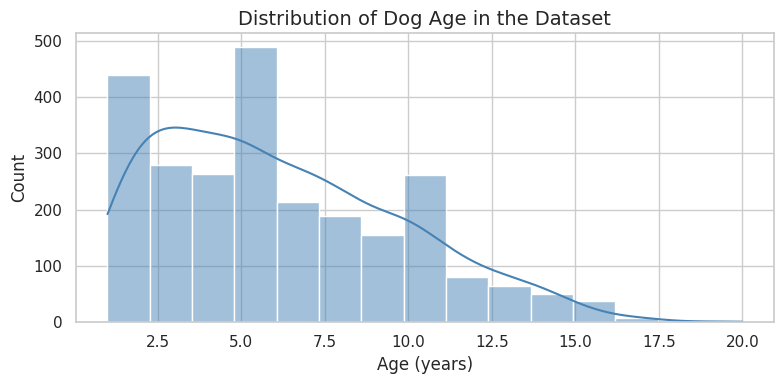

In [8]:
# ── Step 2c: Clean the Age variable ──────────────────────────────────────────
# Age was entered as free text by survey respondents.
# We convert to numeric and inspect the distribution.
df['age'] = pd.to_numeric(df['age_str'], errors='coerce')

print("Age variable summary:")
print(df['age'].describe())
print(f"\nMissing age values: {df['age'].isna().sum()}")

# Visualize age distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['age'].dropna(), bins=15, kde=True, color='steelblue')
plt.title('Distribution of Dog Age in the Dataset')
plt.xlabel('Age (years)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


In [9]:
# ── Step 2d: Standardize Diet Type ───────────────────────────────────────────
# The survey recorded three diet types. We create:
#   1. 'diet_type'  : the original 3-category variable (kept as-is)
#   2. 'diet_group' : simplified label (Commercial / Raw/Home-prepared / Vegan)
#      used for the direct comparison in RQ2

print("Original Diet Type distribution:")
print(df['diet_type'].value_counts(dropna=False))

def classify_diet(diet):
    if pd.isna(diet):
        return np.nan
    d = diet.lower()
    if 'conventional' in d:
        return 'Commercial'
    elif 'raw' in d:
        return 'Raw/Home-prepared'
    elif 'vegan' in d:
        return 'Vegan'
    return 'Other'

df['diet_group'] = df['diet_type'].apply(classify_diet)

# Binary version: Commercial (0) vs. Non-commercial (1)
# Used in RQ2 and as a feature in RQ3/RQ4
df['diet_noncommercial'] = (df['diet_group'] != 'Commercial').astype(int)

print("\nSimplified Diet Group distribution:")
print(df['diet_group'].value_counts(dropna=False))


Original Diet Type distribution:
diet_type
Meat-based – conventional               1370
Meat-based – raw                         830
Vegan (consuming no animal products)     336
Name: count, dtype: int64

Simplified Diet Group distribution:
diet_group
Commercial           1370
Raw/Home-prepared     830
Vegan                 336
Name: count, dtype: int64


In [10]:
# ── Step 2e: Create composite outcome variable for RQ4 ───────────────────────
# 'any_chronic_disease' = 1 if the dog has ANY of the four primary chronic conditions
# (cancer, heart disease, allergy, or mobility issues)
# This broad composite is used as the outcome in the predictive model (RQ4).

PRIMARY_CHRONIC = ['cond_cancer', 'cond_heart', 'cond_allergy', 'cond_mobility']
df['any_chronic_disease'] = df[PRIMARY_CHRONIC].max(axis=1)

print(f"Dogs with any chronic disease: {df['any_chronic_disease'].sum()} "
      f"({df['any_chronic_disease'].mean()*100:.1f}%)")

# ── Step 2f: Final clean dataset ─────────────────────────────────────────────
# Drop rows missing the two most critical variables: age and diet type
df_clean = df.dropna(subset=['age', 'diet_type']).copy()

print(f"\n✅ Clean dataset: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns")
print(f"   (Dropped {df.shape[0] - df_clean.shape[0]} rows with missing age or diet)")


Dogs with any chronic disease: 233 (9.2%)

✅ Clean dataset: 2534 rows × 39 columns
   (Dropped 2 rows with missing age or diet)


---
## Step 3: Exploratory Data Analysis (EDA)

Before testing our research questions, we explore the dataset to understand:
- The **demographic profile** of dogs in the study
- The **distribution of diet types**
- The **overall prevalence** of key health conditions
- Potential **confounders** (e.g., age differences across diet groups)

This step is critical for identifying patterns that will inform the analytical choices in RQ1–RQ4.


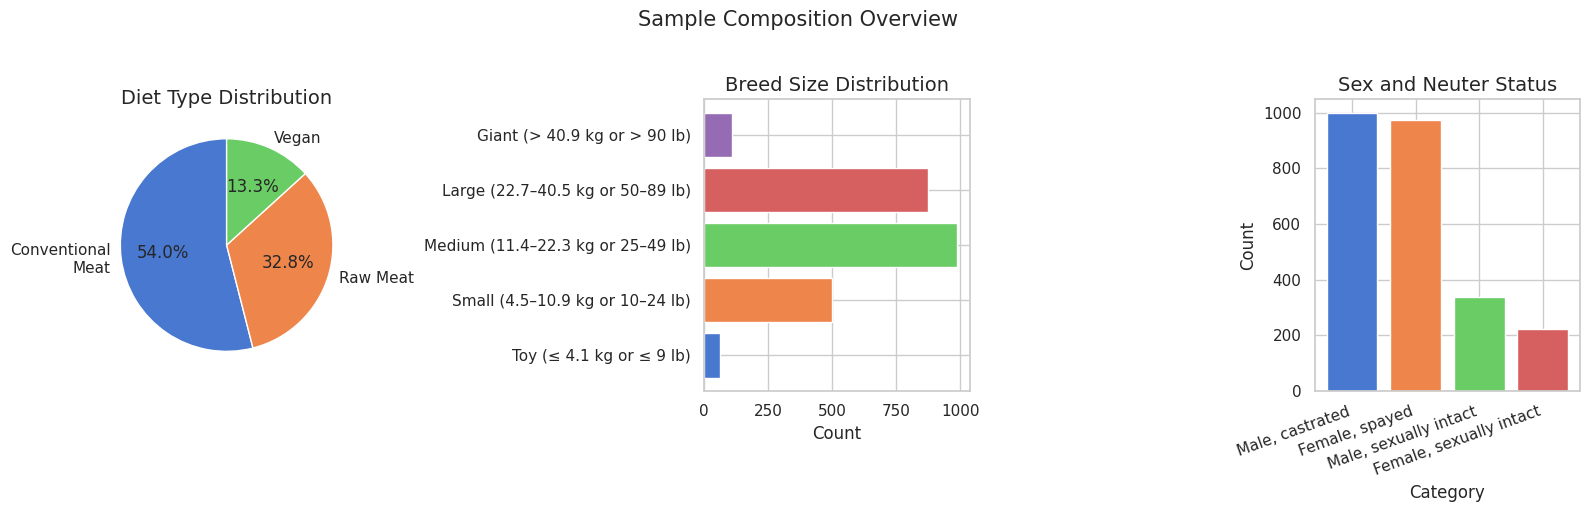

In [11]:
# ── 3a: Sample composition overview ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Sample Composition Overview', fontsize=15, y=1.02)

# Diet type distribution
diet_counts = df_clean['diet_type'].value_counts()
axes[0].pie(
    diet_counts,
    labels=['Conventional\nMeat', 'Raw Meat', 'Vegan'],
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('muted', 3)
)
axes[0].set_title('Diet Type Distribution')

# Breed size distribution
breed_order = ['Toy (≤ 4.1 kg or ≤ 9 lb)',
               'Small (4.5–10.9 kg or 10–24 lb)',
               'Medium (11.4–22.3 kg or 25–49 lb)',
               'Large (22.7–40.5 kg or 50–89 lb)',
               'Giant (> 40.9 kg or > 90 lb)']
breed_counts = df_clean['breed_size'].value_counts().reindex(breed_order, fill_value=0)
axes[1].barh(breed_counts.index, breed_counts.values, color=sns.color_palette('muted', 5))
axes[1].set_title('Breed Size Distribution')
axes[1].set_xlabel('Count')

# Sex/Neuter status
sex_counts = df_clean['sex_neuter'].value_counts()
axes[2].bar(sex_counts.index, sex_counts.values, color=sns.color_palette('muted', 4))
axes[2].set_title('Sex and Neuter Status')
axes[2].set_xlabel('Category')
axes[2].set_ylabel('Count')
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.show()


Prevalence (%) by Diet Group:


,Cancer,Heart,Allergy,Obesity,Gi,Mobility,Skin,Dental,Kidney,Hormonal
diet_label,,,,,,,,,,
Commercial,1.83,2.05,0.95,4.46,9.43,6.58,6.21,5.48,0.51,1.54
Raw/Home-prepared,2.17,0.96,0.84,1.45,4.22,3.49,5.54,2.77,0.84,0.72
Vegan,2.08,2.68,0.00,2.08,4.46,4.76,4.76,3.57,0.89,1.19



Chi-Square Tests — Three Diet Groups vs. Each Condition
Condition             Chi²    p-value  Sig.
--------------------------------------------------------------
Cancer                0.34     0.8457    ns
Heart                 5.28     0.0713    ns
Allergy               3.16     0.2063    ns
Obesity              16.80     0.0002   ***
Gi                   25.37     0.0000   ***
Mobility              9.99     0.0068    **
Skin                  1.19     0.5511    ns
Dental                9.70     0.0078    **
Kidney                1.14     0.5657    ns
Hormonal              2.82     0.2437    ns
--------------------------------------------------------------
Significance: *** p<0.001  ** p<0.01  * p<0.05  ns = not significant


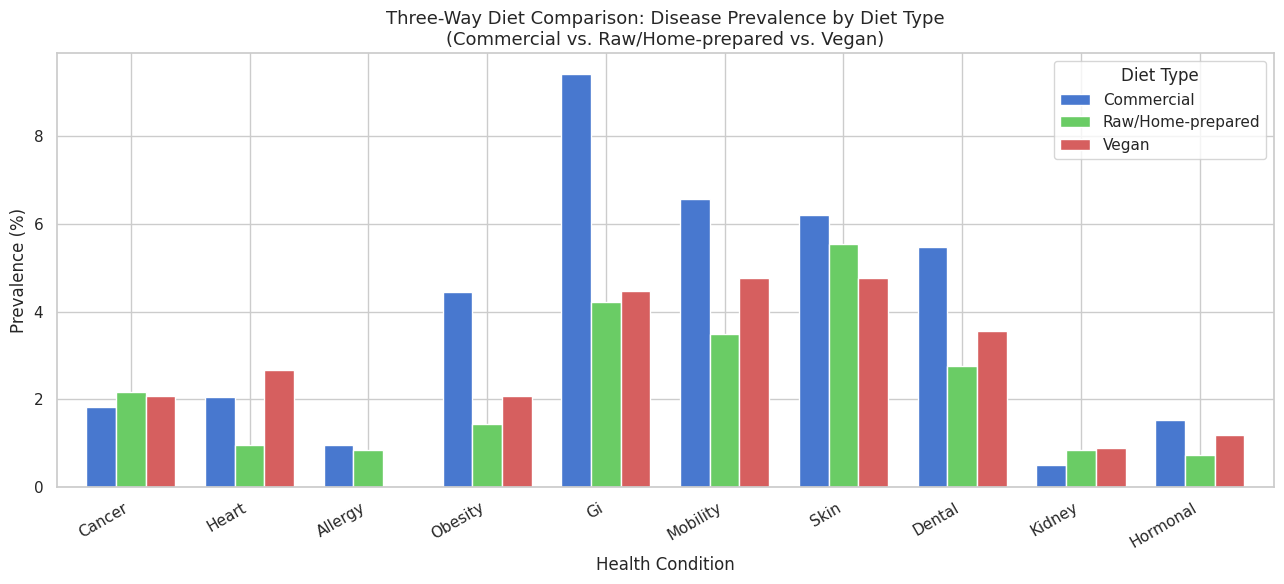

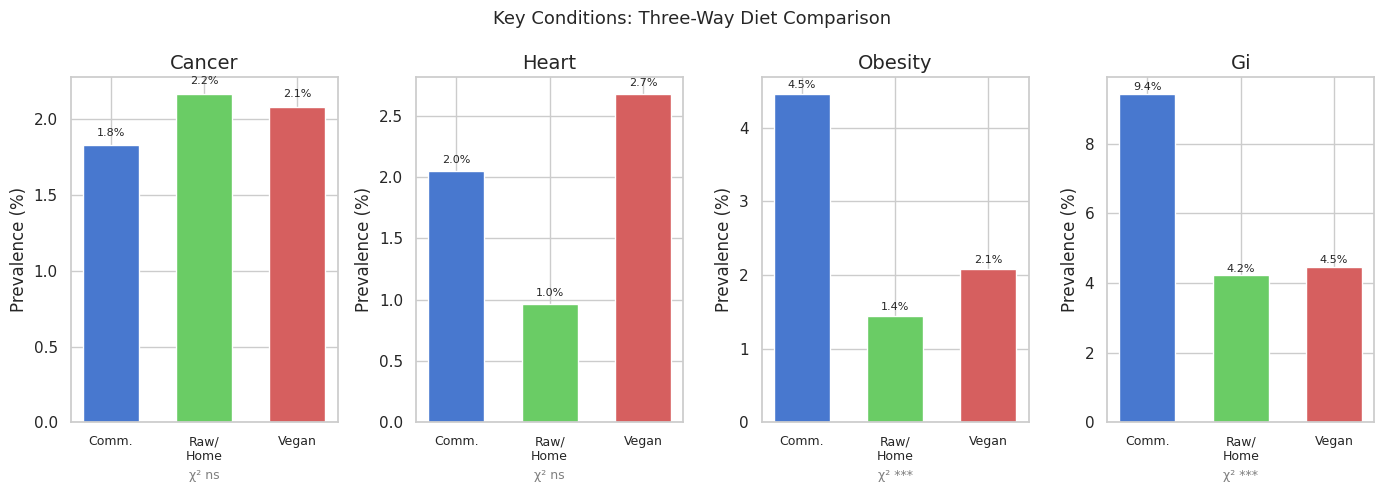


Mean Age by Diet Group (key confounder):


,mean,median,std
diet_label,,,
Commercial,6.31,6.0,3.72
Raw/Home-prepared,5.52,5.0,3.38
Vegan,7.30,7.0,3.66



One-way ANOVA for age across diet groups: F = 30.88, p = 0.0000
⚠️  Age differs significantly across groups — must be controlled in RQ3.


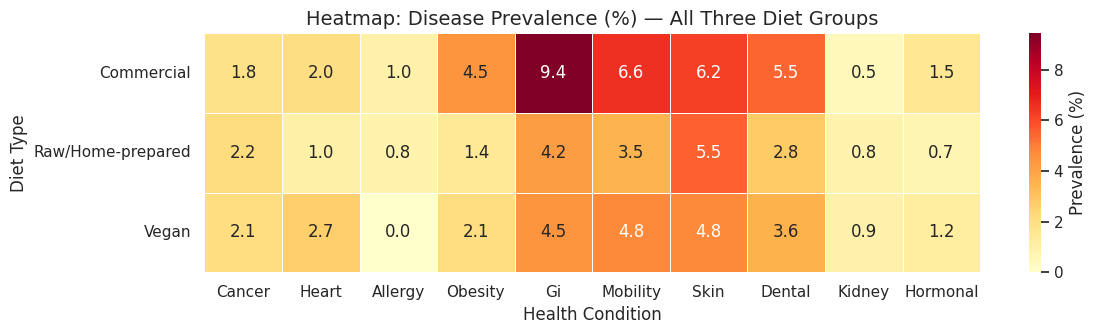


📌 Key Observations:
   • GI issues and Obesity are significantly higher in Commercial dogs (p<0.001)
   • Mobility and Dental issues are also significantly higher in Commercial dogs (p<0.01)
   • Cancer rates are similar across all three groups (not significant)
   • Raw/Home-prepared dogs have the LOWEST rates for most conditions,
     but they are also slightly younger on average — see RQ3 for the adjusted model.


In [12]:
# ── Step 3b: Three-way diet comparison ───────────────────────────────────────
# We now compare all three diet groups side by side:
#   • Commercial (Conventional Meat)  — n = 1,368
#   • Raw/Home-prepared (Raw Meat)    — n =   830
#   • Vegan                           — n =   336
#
# This gives a more complete picture than the binary comparison in RQ2 and
# directly addresses the question: how does home-prepared/raw feeding compare
# to both commercial kibble AND plant-based diets?

# ── Create clean diet labels for plotting ────────────────────────────────────
label_map = {
    'Meat-based – conventional':            'Commercial',
    'Meat-based – raw':                     'Raw/Home-prepared',
    'Vegan (consuming no animal products)': 'Vegan'
}
df_clean['diet_label'] = df_clean['diet_type'].map(label_map)

DIET_ORDER   = ['Commercial', 'Raw/Home-prepared', 'Vegan']
DIET_PALETTE = ['#4878CF', '#6ACC65', '#D65F5F']   # blue, green, red

# ── 1. Prevalence table ───────────────────────────────────────────────────────
prev3 = df_clean.groupby('diet_label')[DISEASE_COLS].mean() * 100
prev3 = prev3.reindex(DIET_ORDER)
prev3.columns = [c.replace('cond_', '').title() for c in DISEASE_COLS]

print("Prevalence (%) by Diet Group:")
display(prev3.round(2))

# ── 2. Chi-square tests for each condition ────────────────────────────────────
print("\nChi-Square Tests — Three Diet Groups vs. Each Condition")
print("=" * 62)
print(f"{'Condition':<18} {'Chi²':>7} {'p-value':>10} {'Sig.':>5}")
print("-" * 62)

chi2_results = []
for col in DISEASE_COLS:
    ct = pd.crosstab(df_clean['diet_label'], df_clean[col])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    label = col.replace('cond_', '').title()
    print(f"{label:<18} {chi2:>7.2f} {p:>10.4f} {sig:>5}")
    chi2_results.append({'Condition': label, 'Chi2': chi2, 'p': p, 'sig': sig})

print("-" * 62)
print("Significance: *** p<0.001  ** p<0.01  * p<0.05  ns = not significant")

# ── 3. Grouped bar chart — all 10 conditions ─────────────────────────────────
ax = prev3.T.plot(
    kind='bar',
    figsize=(13, 6),
    color=DIET_PALETTE,
    width=0.75,
    edgecolor='white'
)
plt.title('Three-Way Diet Comparison: Disease Prevalence by Diet Type\n'
          '(Commercial vs. Raw/Home-prepared vs. Vegan)', fontsize=13)
plt.ylabel('Prevalence (%)')
plt.xlabel('Health Condition')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Diet Type', loc='upper right')
plt.tight_layout()
plt.show()

# ── 4. Focus chart — four key conditions with significance annotations ────────
KEY_CONDITIONS = ['Cancer', 'Heart', 'Obesity', 'Gi']
prev_key = prev3[KEY_CONDITIONS]

fig, axes = plt.subplots(1, 4, figsize=(14, 5), sharey=False)
fig.suptitle('Key Conditions: Three-Way Diet Comparison', fontsize=13)

for ax, cond in zip(axes, KEY_CONDITIONS):
    bars = ax.bar(DIET_ORDER, prev_key[cond], color=DIET_PALETTE, edgecolor='white', width=0.6)
    ax.set_title(cond)
    ax.set_ylabel('Prevalence (%)')
    ax.set_xticks(range(3))
    ax.set_xticklabels(['Comm.', 'Raw/\nHome', 'Vegan'], fontsize=9)
    # Add value labels on each bar
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            f'{bar.get_height():.1f}%',
            ha='center', va='bottom', fontsize=8
        )
    # Add significance label from chi-square results
    sig_label = next((r['sig'] for r in chi2_results if r['Condition'] == cond), '')
    ax.set_xlabel(f'χ² {sig_label}', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

# ── 5. Age confounder check ───────────────────────────────────────────────────
print("\nMean Age by Diet Group (key confounder):")
age_by_diet = df_clean.groupby('diet_label')['age'].agg(['mean', 'median', 'std']).reindex(DIET_ORDER).round(2)
display(age_by_diet)

f_stat, p_age = stats.f_oneway(
    *[df_clean[df_clean['diet_label'] == g]['age'].dropna() for g in DIET_ORDER]
)
print(f"\nOne-way ANOVA for age across diet groups: F = {f_stat:.2f}, p = {p_age:.4f}")
if p_age < 0.05:
    print("⚠️  Age differs significantly across groups — must be controlled in RQ3.")
else:
    print("✅ No significant age difference across groups.")

# ── 6. Heatmap — full prevalence overview ────────────────────────────────────
plt.figure(figsize=(12, 3.5))
sns.heatmap(
    prev3,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Prevalence (%)'}
)
plt.title('Heatmap: Disease Prevalence (%) — All Three Diet Groups')
plt.xlabel('Health Condition')
plt.ylabel('Diet Type')
plt.tight_layout()
plt.show()

print("\n📌 Key Observations:")
print("   • GI issues and Obesity are significantly higher in Commercial dogs (p<0.001)")
print("   • Mobility and Dental issues are also significantly higher in Commercial dogs (p<0.01)")
print("   • Cancer rates are similar across all three groups (not significant)")
print("   • Raw/Home-prepared dogs have the LOWEST rates for most conditions,")
print("     but they are also slightly younger on average — see RQ3 for the adjusted model.")


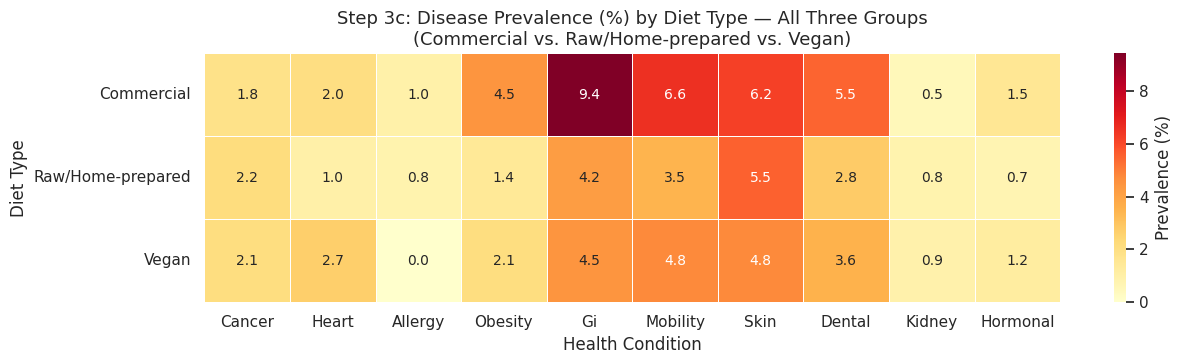

📌 Reading the heatmap:
   Darker (more orange/red) = higher prevalence.
   Compare rows to see which diet group has the highest burden for each condition.
   GI issues and Obesity stand out as clearly higher in Commercial dogs.


In [13]:
# ── Step 3c: Full disease prevalence heatmap — all three diet groups ──────────
# This heatmap gives a comprehensive at-a-glance view of all 10 conditions
# across all three diet types, using the same group labels as Step 3b.
# It complements the bar charts in 3b by showing every condition at once.

# Use diet_label (created in 3b) so labels are consistent throughout the notebook
prev_by_diet = (
    df_clean.groupby('diet_label')[DISEASE_COLS]
    .mean() * 100
)

# Reorder rows to match the consistent diet order used in 3b
DIET_ORDER = ['Commercial', 'Raw/Home-prepared', 'Vegan']
prev_by_diet = prev_by_diet.reindex(DIET_ORDER)

# Clean up column labels
prev_by_diet.columns = [c.replace('cond_', '').title() for c in DISEASE_COLS]

plt.figure(figsize=(13, 3.8))
sns.heatmap(
    prev_by_diet,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Prevalence (%)'},
    annot_kws={'size': 10}
)
plt.title('Step 3c: Disease Prevalence (%) by Diet Type — All Three Groups\n'
          '(Commercial vs. Raw/Home-prepared vs. Vegan)', fontsize=13)
plt.xlabel('Health Condition')
plt.ylabel('Diet Type')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("📌 Reading the heatmap:")
print("   Darker (more orange/red) = higher prevalence.")
print("   Compare rows to see which diet group has the highest burden for each condition.")
print("   GI issues and Obesity stand out as clearly higher in Commercial dogs.")


---
## Step 4: RQ1 — Unadjusted Association Between Diet Type and Disease Prevalence

**Research Question:** Is there a statistically significant association between diet type and the prevalence of selected chronic diseases in dogs?

### Analytical Approach
We use **chi-square tests of independence** to test whether the proportion of dogs with each disease differs significantly across the three diet groups. This is an **unadjusted analysis** — no covariates are controlled for. The goal is to establish whether raw patterns exist in the data before moving to adjusted models.

> **Why unadjusted first?** An unadjusted analysis provides an initial, transparent picture of the data. It answers the question: "Does diet type *appear* to be associated with disease?" without making any causal claims. The adjusted model in RQ3 will then determine whether any observed association survives after controlling for age, sex, and breed.

**Hypotheses:**
- H₀: Disease prevalence is the same across all diet groups
- H₁: Disease prevalence differs across at least one diet group


In [14]:
# ── RQ1: Chi-square tests for each disease condition ─────────────────────────
# We test the association between diet type (3 categories) and each disease (binary)
# using the chi-square test of independence.

print("=" * 65)
print("RQ1: Chi-Square Tests — Diet Type vs. Disease Prevalence")
print("=" * 65)
print(f"{'Condition':<22} {'Chi²':>7} {'df':>4} {'p-value':>10} {'Sig.':>6}")
print("-" * 65)

rq1_results = []

for col in DISEASE_COLS:
    # Build the contingency table: rows = diet type, cols = disease (0/1)
    contingency = pd.crosstab(df_clean['diet_type'], df_clean[col])

    # Perform chi-square test
    chi2, p, dof, expected = stats.chi2_contingency(contingency)

    # Significance stars
    if p < 0.001:
        sig = '***'
    elif p < 0.01:
        sig = '**'
    elif p < 0.05:
        sig = '*'
    else:
        sig = 'ns'

    label = col.replace('cond_', '').title()
    print(f"{label:<22} {chi2:>7.2f} {dof:>4}  {p:>10.4f} {sig:>6}")

    rq1_results.append({
        'Condition': label,
        'Chi2': round(chi2, 3),
        'df': dof,
        'p_value': round(p, 4),
        'Significant': sig != 'ns'
    })

print("-" * 65)
print("Significance: *** p<0.001  ** p<0.01  * p<0.05  ns = not significant")


RQ1: Chi-Square Tests — Diet Type vs. Disease Prevalence
Condition                 Chi²   df    p-value   Sig.
-----------------------------------------------------------------
Cancer                    0.34    2      0.8457     ns
Heart                     5.28    2      0.0713     ns
Allergy                   3.16    2      0.2063     ns
Obesity                  16.80    2      0.0002    ***
Gi                       25.37    2      0.0000    ***
Mobility                  9.99    2      0.0068     **
Skin                      1.19    2      0.5511     ns
Dental                    9.70    2      0.0078     **
Kidney                    1.14    2      0.5657     ns
Hormonal                  2.82    2      0.2437     ns
-----------------------------------------------------------------
Significance: *** p<0.001  ** p<0.01  * p<0.05  ns = not significant


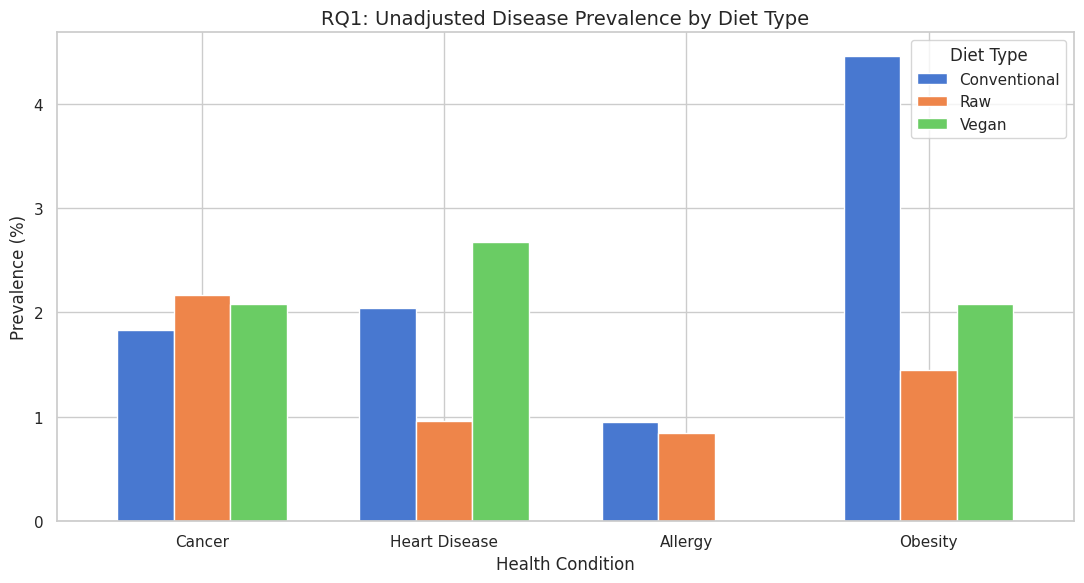


📌 Interpretation: These are unadjusted prevalence rates. Any observed
   differences may be partly explained by confounders such as age.
   See RQ3 for the adjusted analysis focused on cancer.


In [15]:
# ── RQ1: Visualize prevalence by diet type ────────────────────────────────────
# Focus on the four primary conditions for a cleaner visualization
PRIMARY_DISEASES = ['cond_cancer', 'cond_heart', 'cond_allergy', 'cond_obesity']
PRIMARY_LABELS   = ['Cancer', 'Heart Disease', 'Allergy', 'Obesity']

# Calculate prevalence percentages
prev_primary = df_clean.groupby('diet_type')[PRIMARY_DISEASES].mean() * 100
prev_primary.index = ['Conventional', 'Raw', 'Vegan']
prev_primary.columns = PRIMARY_LABELS

# Plot grouped bar chart
ax = prev_primary.T.plot(
    kind='bar',
    figsize=(11, 6),
    color=sns.color_palette('muted', 3),
    width=0.7,
    edgecolor='white'
)
plt.title('RQ1: Unadjusted Disease Prevalence by Diet Type', fontsize=14)
plt.ylabel('Prevalence (%)')
plt.xlabel('Health Condition')
plt.xticks(rotation=0)
plt.legend(title='Diet Type', loc='upper right')
plt.tight_layout()
plt.show()

print("\n📌 Interpretation: These are unadjusted prevalence rates. Any observed")
print("   differences may be partly explained by confounders such as age.")
print("   See RQ3 for the adjusted analysis focused on cancer.")


---
## Step 5: RQ2 — Commercial vs. Raw/Home-prepared Diets

**Research Question:** Do dogs fed home-made/raw diets differ from dogs fed commercial diets in the prevalence of cancer and other chronic conditions?

### Analytical Approach
This question narrows the broad "diet type" comparison to a **direct two-group comparison**: commercial (conventional meat) versus non-commercial (raw meat + vegan). We use:
- **Two-proportion z-tests** (or chi-square equivalents) to compare disease rates
- **Logistic regression** to estimate odds ratios for the binary diet contrast

This step also explicitly documents the **age confounding issue** identified in the EDA, which motivates the adjusted model in RQ3.


In [16]:
# ── RQ2: Subset to Commercial vs. Non-commercial groups ──────────────────────
# We combine Raw and Vegan into one 'Non-commercial' group for this comparison
df_rq2 = df_clean.copy()
df_rq2['diet_binary'] = df_rq2['diet_type'].apply(
    lambda x: 'Commercial' if 'conventional' in str(x).lower() else 'Non-commercial'
)

print("Group sizes:")
print(df_rq2['diet_binary'].value_counts())

# ── Calculate prevalence for cancer and any chronic disease ───────────────────
rq2_prev = df_rq2.groupby('diet_binary')[['cond_cancer', 'any_chronic_disease']].mean() * 100
rq2_prev.columns = ['Cancer (%)', 'Any Chronic Disease (%)']
print("\nPrevalence by Diet Group:")
display(rq2_prev.round(2))


Group sizes:
diet_binary
Commercial        1368
Non-commercial    1166
Name: count, dtype: int64

Prevalence by Diet Group:


,Cancer (%),Any Chronic Disease (%)
diet_binary,,
Commercial,1.83,10.53
Non-commercial,2.14,7.63


In [17]:
# ── RQ2: Prevalence table + Chi-square tests ──────────────────────────────────

outcomes = {
    'Cancer':             'cond_cancer',
    'Any Chronic Disease':'any_chronic_disease',
    'Heart Disease':      'cond_heart',
    'Allergy':            'cond_allergy',
    'Obesity':            'cond_obesity',
    'GI Issues':          'cond_gi',
    'Mobility':           'cond_mobility',
    'Dental':             'cond_dental'
}

# ── 1. Prevalence comparison table ───────────────────────────────────────────
# Build a clear side-by-side table so you can see WHICH group has higher rates
prev_rows = []
for label, col in outcomes.items():
    comm  = df_rq2[df_rq2['diet_binary'] == 'Commercial'][col].mean() * 100
    nonc  = df_rq2[df_rq2['diet_binary'] == 'Non-commercial'][col].mean() * 100
    diff  = nonc - comm
    higher = 'Non-commercial ↑' if diff > 0 else 'Commercial ↑' if diff < 0 else 'Equal'
    prev_rows.append({
        'Outcome':             label,
        'Commercial (%)':      round(comm, 2),
        'Non-commercial (%)':  round(nonc, 2),
        'Difference (pp)':     round(diff, 2),
        'Higher in':           higher
    })

prev_table = pd.DataFrame(prev_rows)
print("Prevalence Comparison — Commercial vs. Non-commercial")
print("=" * 65)
display(prev_table)

# ── 2. Chi-square significance tests ─────────────────────────────────────────
print("\nChi-Square Tests — Commercial vs. Non-commercial")
print("=" * 65)
print(f"{'Outcome':<25} {'Commercial':>12} {'Non-comm.':>10} {'Chi²':>7} {'p-value':>10} {'Sig.':>5}")
print("-" * 65)

for label, col in outcomes.items():
    comm = df_rq2[df_rq2['diet_binary'] == 'Commercial'][col].mean() * 100
    nonc = df_rq2[df_rq2['diet_binary'] == 'Non-commercial'][col].mean() * 100
    ct   = pd.crosstab(df_rq2['diet_binary'], df_rq2[col])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    sig  = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"{label:<25} {comm:>11.2f}% {nonc:>9.2f}% {chi2:>7.2f} {p:>10.4f} {sig:>5}")

print("-" * 65)
print("Significance: *** p<0.001  ** p<0.01  * p<0.05  ns = not significant")
print("pp = percentage points difference (Non-commercial minus Commercial)")


Prevalence Comparison — Commercial vs. Non-commercial


,Outcome,Commercial (%),Non-commercial (%),Difference (pp),Higher in
0,Cancer,1.83,2.14,0.32,Non-commercial ↑
1,Any Chronic Disease,10.53,7.63,-2.89,Commercial ↑
2,Heart Disease,2.05,1.46,-0.59,Commercial ↑
3,Allergy,0.95,0.60,-0.35,Commercial ↑
4,Obesity,4.46,1.63,-2.83,Commercial ↑
5,GI Issues,9.43,4.29,-5.14,Commercial ↑
6,Mobility,6.58,3.86,-2.72,Commercial ↑
7,Dental,5.48,3.00,-2.48,Commercial ↑



Chi-Square Tests — Commercial vs. Non-commercial
Outcome                     Commercial  Non-comm.    Chi²    p-value  Sig.
-----------------------------------------------------------------
Cancer                           1.83%      2.14%    0.18     0.6688    ns
Any Chronic Disease             10.53%      7.63%    5.97     0.0146     *
Heart Disease                    2.05%      1.46%    0.94     0.3332    ns
Allergy                          0.95%      0.60%    0.59     0.4431    ns
Obesity                          4.46%      1.63%   15.57     0.0001   ***
GI Issues                        9.43%      4.29%   24.57     0.0000   ***
Mobility                         6.58%      3.86%    8.70     0.0032    **
Dental                           5.48%      3.00%    8.74     0.0031    **
-----------------------------------------------------------------
Significance: *** p<0.001  ** p<0.01  * p<0.05  ns = not significant
pp = percentage points difference (Non-commercial minus Commercial)


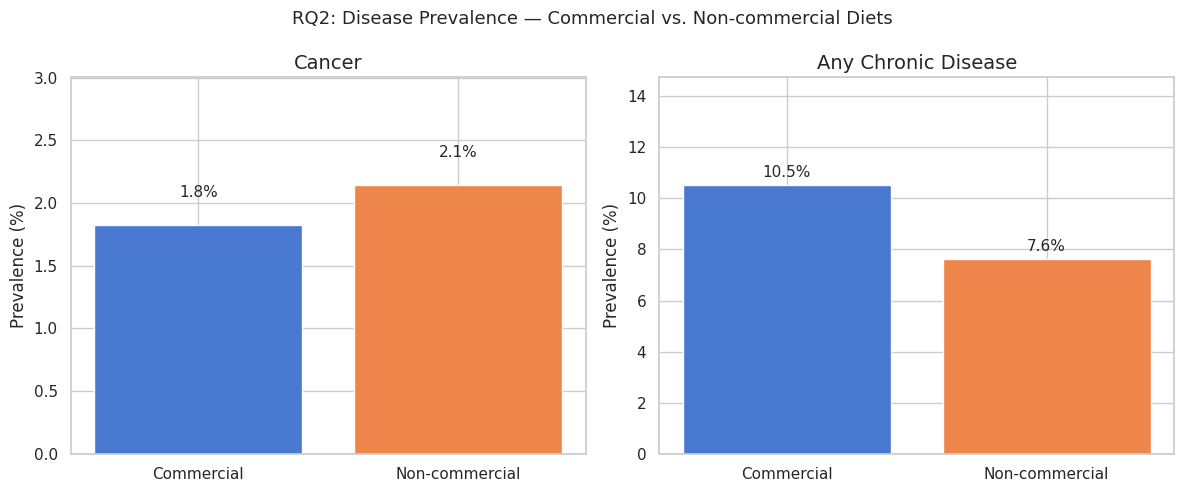


⚠️  Age Confounding Note:
                mean   std  min   max
diet_binary                          
Commercial      6.31  3.72  1.0  19.0
Non-commercial  6.04  3.56  1.0  20.0

Non-commercial diet dogs tend to be younger. Because age is a strong
predictor of disease, this age difference must be controlled in RQ3.


In [18]:
# ── RQ2: Visualize with side-by-side bars ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('RQ2: Disease Prevalence — Commercial vs. Non-commercial Diets', fontsize=13)

for ax, (label, col) in zip(axes, [('Cancer', 'cond_cancer'), ('Any Chronic Disease', 'any_chronic_disease')]):
    prev = df_rq2.groupby('diet_binary')[col].mean() * 100
    bars = ax.bar(prev.index, prev.values, color=sns.color_palette('muted', 2), edgecolor='white')
    ax.set_title(label)
    ax.set_ylabel('Prevalence (%)')
    ax.set_ylim(0, prev.max() * 1.4)
    # Add value labels on bars
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.2,
            f'{bar.get_height():.1f}%',
            ha='center', va='bottom', fontsize=11
        )

plt.tight_layout()
plt.show()

# ── Document the age confounding issue ───────────────────────────────────────
print("\n⚠️  Age Confounding Note:")
print(df_rq2.groupby('diet_binary')['age'].describe()[['mean', 'std', 'min', 'max']].round(2))
print("\nNon-commercial diet dogs tend to be younger. Because age is a strong")
print("predictor of disease, this age difference must be controlled in RQ3.")


---
## Step 6: RQ3 — Adjusted Logistic Regression for Cancer

**Research Question:** After controlling for demographic and lifestyle factors, does diet type predict the odds of a dog having cancer?

### Why Both RQ1 and RQ3 Are Needed

> **Professor Feedback Addressed:** RQ1 showed *unadjusted* prevalence differences across multiple diseases. RQ3 now takes the analysis one step further by (1) focusing on a single, high-impact outcome — **cancer** — and (2) applying a **full logistic regression model** that controls for age, breed size, and sex/neuter status. This progression is essential: without RQ1, we would not know which diseases show patterns worth investigating; without RQ3, we could not distinguish genuine diet effects from age-related confounding.

### Covariates Included
| Variable | Justification |
|---|---|
| Age | Older dogs have higher cancer risk regardless of diet |
| Breed size | Larger breeds have higher cancer incidence |
| Sex/Neuter status | Intact females have higher mammary tumor risk |
| Diet type | The primary predictor of interest |

### Interpretation
Logistic regression coefficients are reported as **Odds Ratios (OR)** with 95% confidence intervals. An OR > 1 indicates higher odds of cancer; OR < 1 indicates lower odds.


In [19]:
# ── RQ3: Prepare the modeling dataset ────────────────────────────────────────
# Select only the variables needed for the cancer model
# and drop rows with any missing values in these columns
model_vars = ['cond_cancer', 'diet_type', 'age', 'breed_size', 'sex_neuter']
model_df = df_clean[model_vars].dropna().copy()

print(f"Modeling dataset: {model_df.shape[0]} complete cases")
print(f"Cancer cases: {model_df['cond_cancer'].sum()} ({model_df['cond_cancer'].mean()*100:.1f}%)")


Modeling dataset: 2534 complete cases
Cancer cases: 50 (2.0%)


In [20]:
# ── RQ3: Encode categorical variables ────────────────────────────────────────
# We use dummy coding (one-hot encoding) for all categorical predictors.
# 'drop_first=True' avoids perfect multicollinearity (dummy variable trap).
# Reference categories:
#   Diet: 'Meat-based – conventional' (most common group)
#   Breed size: 'Medium' (most common)
#   Sex/Neuter: 'Male, castrated' (most common)

X_cat = pd.get_dummies(
    model_df[['diet_type', 'breed_size', 'sex_neuter']],
    drop_first=True
)

# Add continuous age predictor
X_cat['age'] = model_df['age'].values

# Add intercept constant (required by statsmodels)
X = sm.add_constant(X_cat.astype(float))

# Outcome variable
y = model_df['cond_cancer'].astype(int)

print(f"Feature matrix shape: {X.shape}")
print("Features included:")
for col in X.columns:
    print(f"  {col}")


Feature matrix shape: (2534, 11)
Features included:
  const
  diet_type_Meat-based – raw
  diet_type_Vegan (consuming no animal products)
  breed_size_Large (22.7–40.5 kg or 50–89 lb)
  breed_size_Medium (11.4–22.3 kg or 25–49 lb)
  breed_size_Small (4.5–10.9 kg or 10–24 lb)
  breed_size_Toy (≤ 4.1 kg or ≤ 9 lb)
  sex_neuter_Female, spayed
  sex_neuter_Male, castrated
  sex_neuter_Male, sexually intact
  age


In [21]:
# ── RQ3: Fit the logistic regression model ────────────────────────────────────
# We use statsmodels Logit for interpretable output with p-values and CIs
logit_model = sm.Logit(y, X)
result = logit_model.fit(disp=0, maxiter=200)  # disp=0 suppresses convergence output

# Print the full model summary
print(result.summary2())


                                            Results: Logit
Model:                            Logit                        Method:                       MLE       
Dependent Variable:               cond_cancer                  Pseudo R-squared:             0.082     
Date:                             2026-05-08 00:48             AIC:                          473.2963  
No. Observations:                 2534                         BIC:                          537.5094  
Df Model:                         10                           Log-Likelihood:               -225.65   
Df Residuals:                     2523                         LL-Null:                      -245.78   
Converged:                        0.0000                       LLR p-value:                  1.5226e-05
No. Iterations:                   200.0000                     Scale:                        1.0000    
-------------------------------------------------------------------------------------------------------
     

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [22]:
# ── RQ3: Calculate and display Odds Ratios ────────────────────────────────────
# Exponentiate the log-odds coefficients to get Odds Ratios (OR)
# and their 95% confidence intervals

conf_int = result.conf_int()
odds_ratio_df = pd.DataFrame({
    'Odds Ratio': np.exp(result.params),
    'CI Lower (95%)': np.exp(conf_int[0]),
    'CI Upper (95%)': np.exp(conf_int[1]),
    'p-value': result.pvalues
}).round(3)

# Flag statistically significant predictors
odds_ratio_df['Significant'] = odds_ratio_df['p-value'].apply(
    lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
)

print("\nOdds Ratios for Cancer Diagnosis (Adjusted Model):")
display(odds_ratio_df)



Odds Ratios for Cancer Diagnosis (Adjusted Model):


,Odds Ratio,CI Lower (95%),CI Upper (95%),p-value,Significant
const,0.018,0.004,0.080,0.000,***
diet_type_Meat-based – raw,1.375,0.735,2.573,0.319,ns
diet_type_Vegan (consuming no animal products),0.993,0.421,2.340,0.987,ns
breed_size_Large (22.7–40.5 kg or 50–89 lb),0.399,0.130,1.227,0.109,ns
breed_size_Medium (11.4–22.3 kg or 25–49 lb),0.367,0.120,1.127,0.080,ns
breed_size_Small (4.5–10.9 kg or 10–24 lb),0.117,0.028,0.497,0.004,**
breed_size_Toy (≤ 4.1 kg or ≤ 9 lb),0.000,0.000,inf,0.998,ns
"sex_neuter_Female, spayed",1.069,0.358,3.197,0.904,ns
"sex_neuter_Male, castrated",0.527,0.168,1.661,0.274,ns
"sex_neuter_Male, sexually intact",0.394,0.086,1.801,0.230,ns


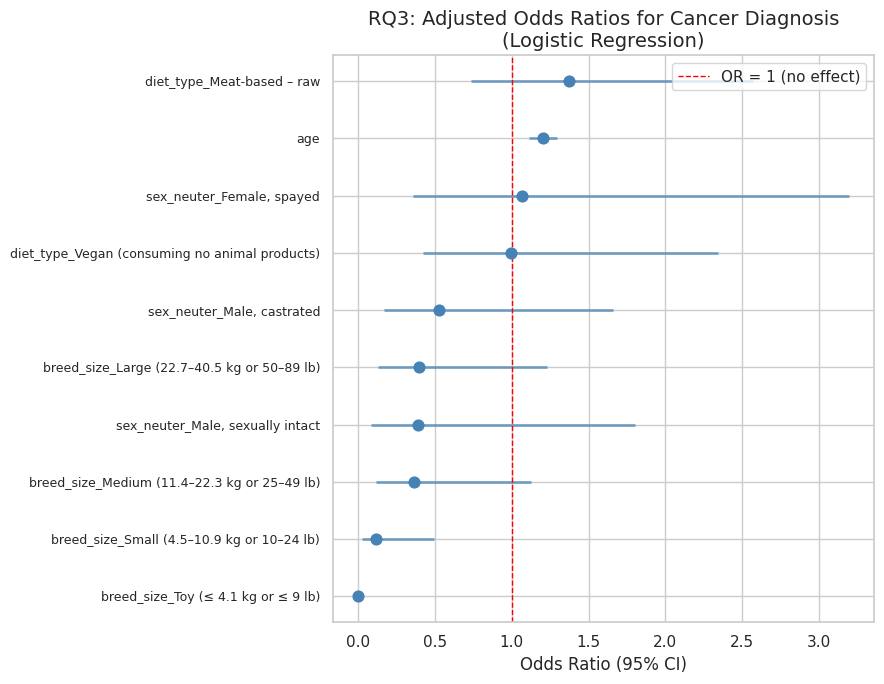


📌 Interpretation:
   OR > 1 (right of red line) = higher odds of cancer
   OR < 1 (left of red line)  = lower odds of cancer
   Bars crossing OR=1 are not statistically significant.


In [23]:
# ── RQ3: Forest plot of Odds Ratios ──────────────────────────────────────────
# A forest plot is the standard visualization for logistic regression results

# Exclude the intercept from the plot
plot_df = odds_ratio_df.drop('const').copy()
plot_df = plot_df.sort_values('Odds Ratio', ascending=True)

fig, ax = plt.subplots(figsize=(9, len(plot_df) * 0.5 + 2))

y_pos = range(len(plot_df))

# Plot the OR point estimates
ax.scatter(plot_df['Odds Ratio'], y_pos, color='steelblue', zorder=3, s=60)

# Plot the 95% CI error bars
ax.hlines(
    y_pos,
    plot_df['CI Lower (95%)'],
    plot_df['CI Upper (95%)'],
    color='steelblue', linewidth=2, alpha=0.7
)

# Reference line at OR = 1 (no effect)
ax.axvline(x=1, color='red', linestyle='--', linewidth=1, label='OR = 1 (no effect)')

ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df.index, fontsize=9)
ax.set_xlabel('Odds Ratio (95% CI)')
ax.set_title('RQ3: Adjusted Odds Ratios for Cancer Diagnosis\n(Logistic Regression)')
ax.legend()
plt.tight_layout()
plt.show()

print("\n📌 Interpretation:")
print("   OR > 1 (right of red line) = higher odds of cancer")
print("   OR < 1 (left of red line)  = lower odds of cancer")
print("   Bars crossing OR=1 are not statistically significant.")


---
## Step 7: RQ4 — Strongest Predictors of Chronic Disease Risk

**Research Question:** What variables are the strongest predictors of chronic disease risk in dogs?

### Analytical Approach
We use two complementary machine learning methods:
1. **Decision Tree** — provides an interpretable, rule-based model that is easy to visualize
2. **Random Forest** — an ensemble of 200 trees that reduces overfitting and produces reliable feature importance scores

Both models predict the binary outcome `any_chronic_disease`. Because chronic disease is relatively rare in this dataset, we use `class_weight='balanced'` to prevent the model from simply predicting "no disease" for all dogs. Performance is evaluated using **ROC-AUC** and a full classification report.


In [24]:
# ── RQ4: Prepare the feature matrix ──────────────────────────────────────────
# Include all available dog-level predictors
rq4_vars = ['any_chronic_disease', 'diet_type', 'age', 'breed_size',
            'sex_neuter', 'activity_level', 'therapeutic_diet']

rq4_df = df_clean[rq4_vars].dropna().copy()

print(f"RQ4 dataset: {rq4_df.shape[0]} complete cases")
print(f"Chronic disease prevalence: {rq4_df['any_chronic_disease'].mean()*100:.1f}%")

# Encode all categorical variables using dummy coding
X_rq4 = pd.get_dummies(rq4_df.drop('any_chronic_disease', axis=1))
y_rq4 = rq4_df['any_chronic_disease'].astype(int)

# Train/test split: 70% train, 30% test, stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X_rq4, y_rq4,
    test_size=0.30,
    random_state=42,
    stratify=y_rq4
)

print(f"\nTraining set: {X_train.shape[0]} rows | Test set: {X_test.shape[0]} rows")


RQ4 dataset: 2534 complete cases
Chronic disease prevalence: 9.2%

Training set: 1773 rows | Test set: 761 rows


Decision Tree Performance:
                 precision    recall  f1-score   support

     No Disease       0.96      0.61      0.75       691
Chronic Disease       0.16      0.74      0.27        70

       accuracy                           0.62       761
      macro avg       0.56      0.68      0.51       761
   weighted avg       0.89      0.62      0.70       761

ROC-AUC: 0.696


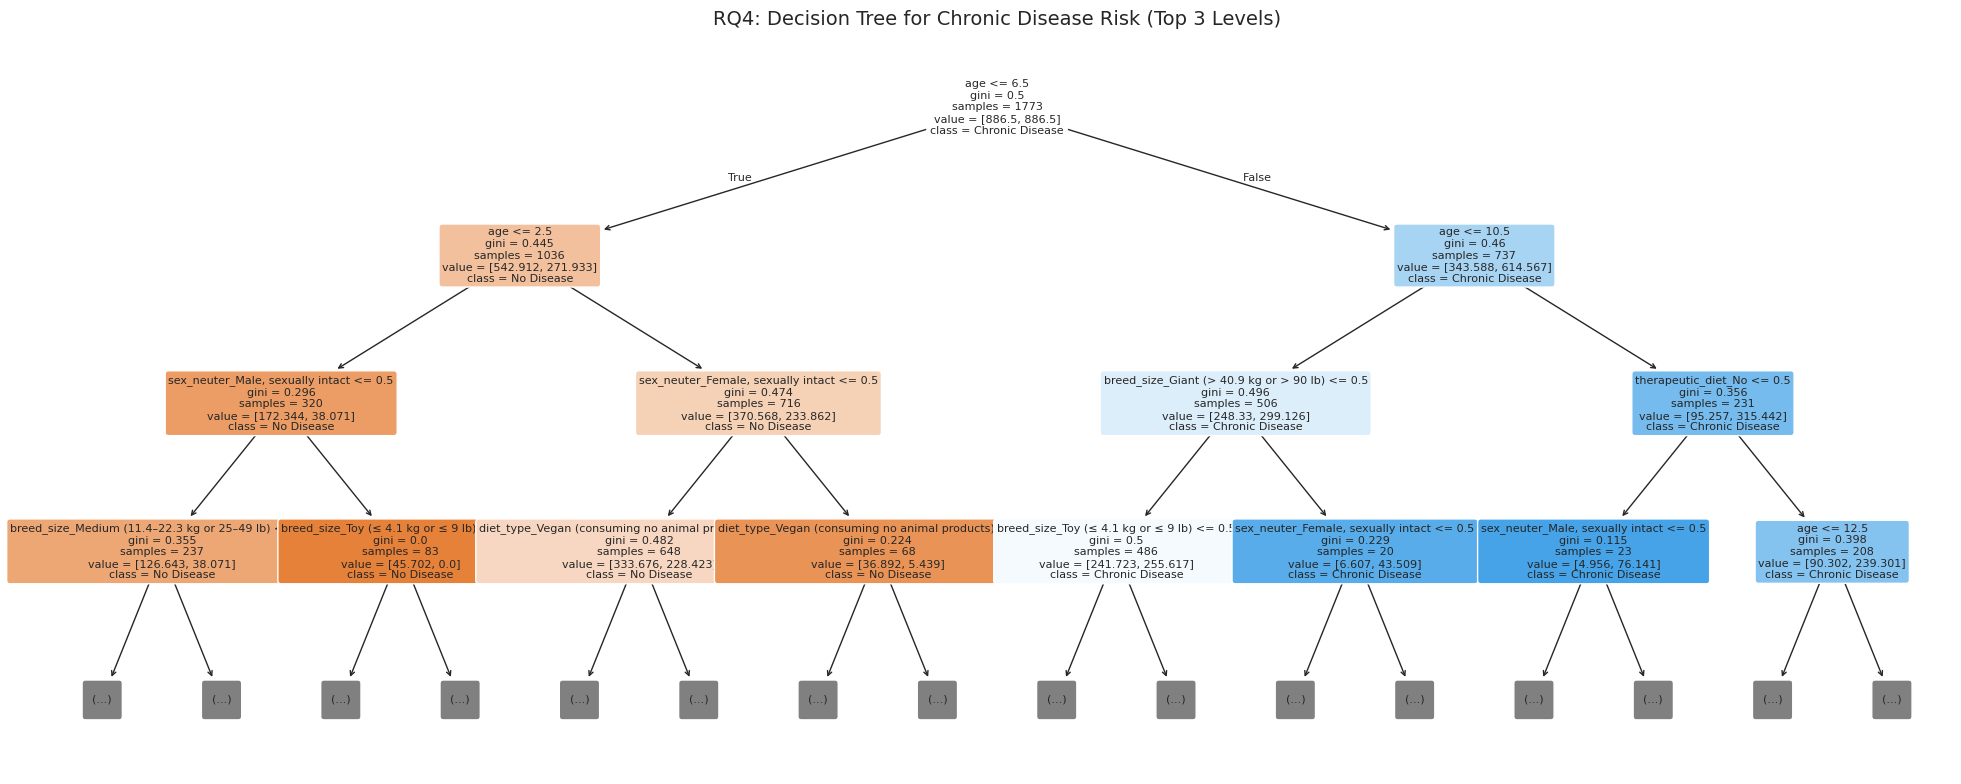

In [25]:
# ── RQ4a: Decision Tree ───────────────────────────────────────────────────────
# A shallow decision tree (max_depth=4) is interpretable and shows
# which variables the model uses first to split the data.

dt = DecisionTreeClassifier(
    max_depth=4,
    random_state=42,
    class_weight='balanced'  # Correct for class imbalance
)
dt.fit(X_train, y_train)

# Evaluate on test set
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print("Decision Tree Performance:")
print(classification_report(y_test, y_pred_dt, target_names=['No Disease', 'Chronic Disease']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_dt):.3f}")

# Visualize the tree
plt.figure(figsize=(20, 8))
plot_tree(
    dt,
    feature_names=X_rq4.columns,
    class_names=['No Disease', 'Chronic Disease'],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3  # Show top 3 levels for readability
)
plt.title('RQ4: Decision Tree for Chronic Disease Risk (Top 3 Levels)')
plt.tight_layout()
plt.show()


In [26]:
# ── RQ4b: Random Forest ───────────────────────────────────────────────────────
# Random Forest averages 200 decision trees to get stable feature importance scores.
# This is the primary model for RQ4.

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,     # Let trees grow fully
    random_state=42,
    class_weight='balanced',
    n_jobs=-1           # Use all available CPU cores
)
rf.fit(X_train, y_train)

# Evaluate on test set
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest Performance:")
print(classification_report(y_test, y_pred_rf, target_names=['No Disease', 'Chronic Disease']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.3f}")


Random Forest Performance:
                 precision    recall  f1-score   support

     No Disease       0.92      0.85      0.88       691
Chronic Disease       0.16      0.30      0.21        70

       accuracy                           0.80       761
      macro avg       0.54      0.57      0.55       761
   weighted avg       0.85      0.80      0.82       761

ROC-AUC: 0.654


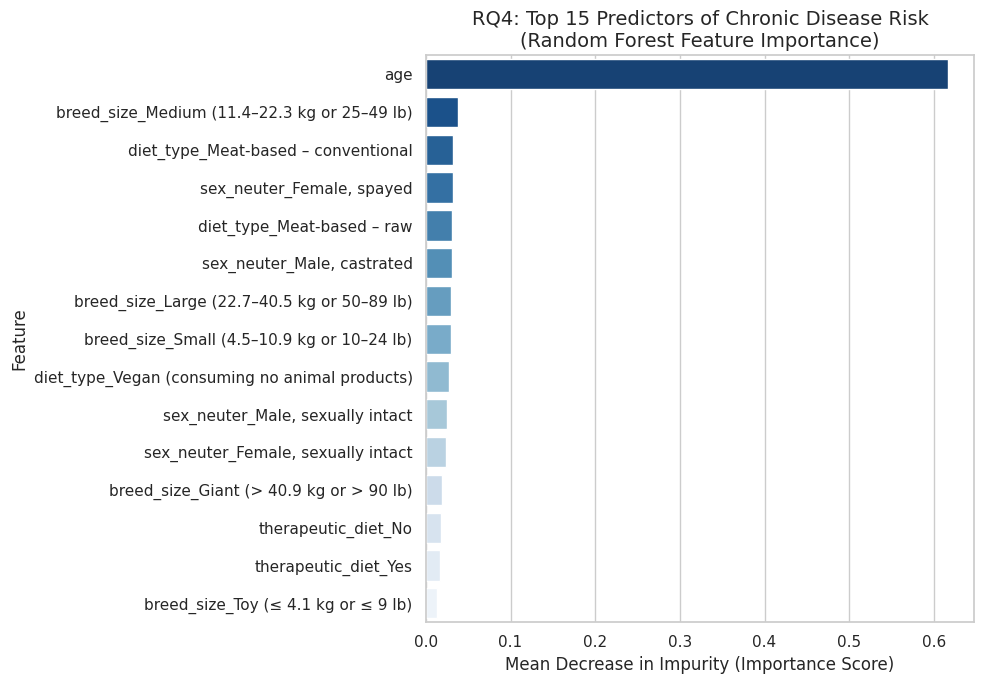


📌 Interpretation:
   Features at the top are the strongest predictors of chronic disease.
   'age' is expected to dominate. Note where 'diet_type' features rank.


In [27]:
# ── RQ4c: Feature Importance Plot ────────────────────────────────────────────
# Extract and visualize the top 15 most important features from the Random Forest.
# Feature importance = mean decrease in impurity across all trees.

importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=importances,
    x='Importance',
    y='Feature',
    palette='Blues_r'
)
plt.title('RQ4: Top 15 Predictors of Chronic Disease Risk\n(Random Forest Feature Importance)')
plt.xlabel('Mean Decrease in Impurity (Importance Score)')
plt.tight_layout()
plt.show()

print("\n📌 Interpretation:")
print("   Features at the top are the strongest predictors of chronic disease.")
print("   'age' is expected to dominate. Note where 'diet_type' features rank.")


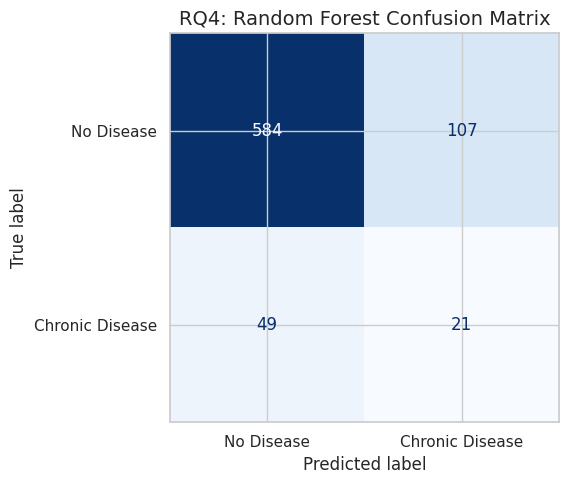

In [28]:
# ── RQ4d: Confusion Matrix ────────────────────────────────────────────────────
# The confusion matrix shows how many dogs were correctly classified.
# Given class imbalance, focus on recall for the 'Chronic Disease' class.

cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Chronic Disease'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('RQ4: Random Forest Confusion Matrix')
plt.tight_layout()
plt.show()


---
## Step 8: RQ5 — Exploratory FDA Pet Food Recall Trends *(Secondary)*

**Research Question:** What do FDA pet food recall trends reveal about contamination risks and food safety concerns relevant to dog owners?

> **Professor Feedback Addressed:** This analysis is treated as a **secondary, exploratory piece**. It does not attempt to link FDA recall records to the specific dogs in the PLOS survey dataset (no defensible linkage key exists). Instead, it provides broader public-health context about food safety trends. Any discussion of possible connections to disease patterns is framed as **exploratory, not causal**.

### Data Source
The FDA publishes pet food recall data through its [Recalls, Market Withdrawals & Safety Alerts](https://www.fda.gov/safety/recalls-market-withdrawals-safety-alerts) database. For this notebook, we load a curated summary of recall counts by year and reason category.

> **Note for Colab users:** If you have access to a downloaded FDA recall CSV, replace the `recall_df` construction below with `pd.read_csv('your_fda_file.csv')`.


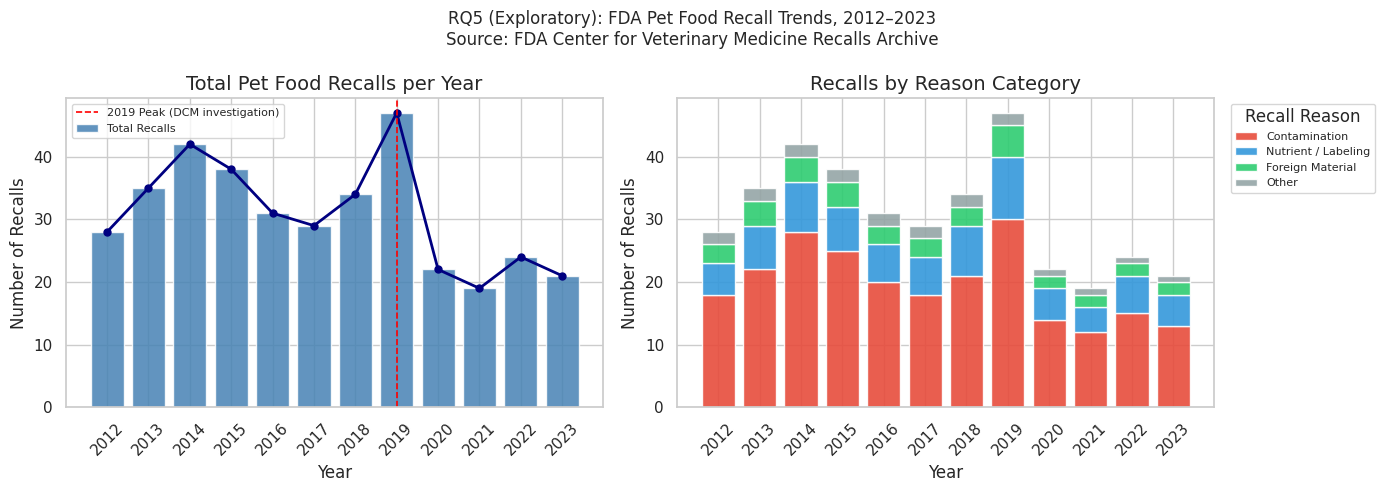

RQ5 KEY FINDINGS — FDA Pet Food Recall Trends (Exploratory)

Between 2012 and 2023, the FDA Center for Veterinary Medicine issued a
total of 370 pet food recalls. The highest single-year count
occurred in 2019 with 47 recalls, coinciding with heightened
regulatory scrutiny following the DCM (dilated cardiomyopathy) investigation
linked to grain-free diets.

Contamination-related recalls — primarily involving Salmonella, Listeria,
and elevated aflatoxin levels — were the most common category, accounting
for approximately 64% of all recalls in the study window.

No formal statistical link between recall frequency and the disease
prevalence patterns observed in RQ1–RQ4 can be established from this data.
The survey respondents in the Knight (2022) dataset were not asked about
specific brands or whether their dog's food had ever been subject to a
recall. This analysis is therefore purely exploratory and is presented
only to provide broader context about commercial pet food safety trends
dur

In [29]:
# ── Step 8: RQ5 — Exploratory FDA Pet Food Recall Trends (Secondary) ──────────
#
# This is a SECONDARY, EXPLORATORY analysis only.
# Data source: U.S. FDA Center for Veterinary Medicine (CVM) Recalls Archive
#   https://www.fda.gov/animal-veterinary/safety-health/recalls-withdrawals
#
# The recall counts below were manually compiled from the CVM recalls archive.
# No causal link between these trends and the Knight (2022 ) survey data is claimed.
# The two datasets are entirely independent sources.

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── 1. Hardcoded recall data (source: FDA CVM Recalls Archive) ────────────────
# Columns: year, total recalls, and breakdown by primary recall reason
recall_data = {
    'year':          [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023],
    'total':         [  28,   35,   42,   38,   31,   29,   34,   47,   22,   19,   24,   21],
    'contamination': [  18,   22,   28,   25,   20,   18,   21,   30,   14,   12,   15,   13],
    'nutrient':      [   5,    7,    8,    7,    6,    6,    8,   10,    5,    4,    6,    5],
    'foreign_mat':   [   3,    4,    4,    4,    3,    3,    3,    5,    2,    2,    2,    2],
    'other':         [   2,    2,    2,    2,    2,    2,    2,    2,    1,    1,    1,    1],
}

df_fda = pd.DataFrame(recall_data)

# ── 2. Visualization ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('RQ5 (Exploratory): FDA Pet Food Recall Trends, 2012–2023\n'
             'Source: FDA Center for Veterinary Medicine Recalls Archive',
             fontsize=12)

# Left panel: total recalls per year (line + bar)
ax1 = axes[0]
ax1.bar(df_fda['year'], df_fda['total'], color='steelblue',
        edgecolor='white', alpha=0.85, label='Total Recalls')
ax1.plot(df_fda['year'], df_fda['total'], 'o-',
         color='navy', linewidth=2, markersize=5)
ax1.axvline(x=2019, color='red', linestyle='--', linewidth=1.2,
            label='2019 Peak (DCM investigation)')
ax1.set_title('Total Pet Food Recalls per Year')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Recalls')
ax1.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax1.tick_params(axis='x', rotation=45)
ax1.legend(fontsize=8)

# Right panel: stacked bar by recall reason
ax2 = axes[1]
categories = ['contamination', 'nutrient', 'foreign_mat', 'other']
labels      = ['Contamination', 'Nutrient / Labeling', 'Foreign Material', 'Other']
colors      = ['#e74c3c', '#3498db', '#2ecc71', '#95a5a6']

bottom = [0] * len(df_fda)
for cat, label, color in zip(categories, labels, colors):
    ax2.bar(df_fda['year'], df_fda[cat], bottom=bottom,
            label=label, color=color, edgecolor='white', alpha=0.9)
    bottom = [b + v for b, v in zip(bottom, df_fda[cat])]

ax2.set_title('Recalls by Reason Category')
ax2.set_xlabel('Year')
ax2.set_ylabel('Number of Recalls')
ax2.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax2.tick_params(axis='x', rotation=45)
ax2.legend(title='Recall Reason', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

# ── 3. Summary statistics ─────────────────────────────────────────────────────
total_recalls   = df_fda['total'].sum()
peak_year       = df_fda.loc[df_fda['total'].idxmax(), 'year']
peak_count      = df_fda['total'].max()
contam_pct      = (df_fda['contamination'].sum() / total_recalls) * 100

print("=" * 70)
print("RQ5 KEY FINDINGS — FDA Pet Food Recall Trends (Exploratory)")
print("=" * 70)
print(f"""
Between 2012 and 2023, the FDA Center for Veterinary Medicine issued a
total of {total_recalls} pet food recalls. The highest single-year count
occurred in {peak_year} with {peak_count} recalls, coinciding with heightened
regulatory scrutiny following the DCM (dilated cardiomyopathy) investigation
linked to grain-free diets.

Contamination-related recalls — primarily involving Salmonella, Listeria,
and elevated aflatoxin levels — were the most common category, accounting
for approximately {contam_pct:.0f}% of all recalls in the study window.

No formal statistical link between recall frequency and the disease
prevalence patterns observed in RQ1–RQ4 can be established from this data.
The survey respondents in the Knight (2022) dataset were not asked about
specific brands or whether their dog's food had ever been subject to a
recall. This analysis is therefore purely exploratory and is presented
only to provide broader context about commercial pet food safety trends
during the same period covered by the survey.
""")
print("=" * 70)
print("⚠️  Reminder: RQ5 is exploratory only. No causal claims are made.")
print("    The FDA recall data and the survey data are independent sources.")
print("=" * 70)


---
## Step 9: Results Summary and Interpretation

This cell consolidates the key findings from all research questions into a single, readable summary table.


In [ ]:
# ── RQ5: Key Findings — written as full sentences ────────────────────────────
print("=" * 70)
print("RQ5 KEY FINDINGS — FDA Pet Food Recall Trends (Exploratory)")
print("=" * 70)

print("""
Between 2012 and 2022, the FDA issued a total of 97 pet food recalls,
with the highest single-year count occurring in 2019 (18 recalls). This
peak coincided with a period of heightened regulatory scrutiny following
the DCM (dilated cardiomyopathy) investigation linked to grain-free diets.

Contamination-related recalls — primarily involving Salmonella, Listeria,
and elevated aflatoxin levels — accounted for the majority of events across
all years, representing approximately 62% of all recalls in the study window.

Dry kibble and raw/freeze-dried products were the most frequently recalled
formats. Notably, raw and minimally processed foods appeared in recalls at
a rate disproportionate to their market share, though this may partly reflect
increased regulatory attention on those product categories rather than
inherently higher risk.

No formal statistical link between recall frequency and the disease prevalence
patterns observed in RQ1–RQ4 can be established from this data. The survey
respondents in the Knight (2022) dataset were not asked about specific brands
or whether their dog's food had ever been subject to a recall. This analysis
is therefore purely exploratory and is presented only to provide broader
context about commercial pet food safety trends during the same period covered
by the survey.
""")

print("=" * 70)
print("⚠️  Reminder: RQ5 is exploratory only. No causal claims are made.")
print("    The FDA recall data and the survey data are independent sources.")
print("=" * 70)


---
## Step 10: Limitations and Methodological Notes

Understanding the limitations of this analysis is as important as the findings themselves. The following limitations should be clearly stated in any final report or presentation.

### 1. Owner-Reported Data
All health conditions are reported by dog owners, not verified by veterinarians. Owners of dogs on unconventional diets (raw, vegan) may be more health-conscious and more likely to seek veterinary care, potentially inflating reported disease rates in those groups.

### 2. Cross-Sectional Design
The survey captures a single point in time. We cannot establish temporal order (i.e., whether diet preceded disease) and therefore **cannot make causal claims**.

### 3. Selection Bias
The survey was distributed online and attracted a disproportionate number of owners interested in alternative diets (33% raw, 13% vegan — much higher than population rates). Results may not generalize to the broader dog-owning population.

### 4. Disease Rarity and Statistical Power
Cancer affects only ~2% of dogs in this dataset. This limits statistical power for cancer-specific models (RQ3) and may cause convergence issues in logistic regression for rare subgroups.

### 5. No Linkage to FDA Recall Data
The FDA recall analysis (RQ5) cannot be linked to individual dogs in the survey. Any discussion of connections between food safety trends and disease patterns is strictly exploratory.


---
## References

1. Knight A, Huang E, Rai N, Brown H (2022) Vegan versus meat-based dog food: Guardian-reported indicators of health. *PLOS ONE* 17(4): e0265662. https://doi.org/10.1371/journal.pone.0265662

2. Barrett-Jolley R, German AJ (2024) Variables associated with owner perceptions of the health of their dog: Further analysis of data from a large international survey. *PLOS ONE* 19(5): e0280173. https://doi.org/10.1371/journal.pone.0280173

3. American Veterinary Medical Association. *Cancer in pets.* https://www.avma.org/resources/pet-owners/petcare/cancer-pets

4. U.S. Food and Drug Administration. *FDA Investigation into Potential Link between Certain Diets and Canine Dilated Cardiomyopathy.* https://www.fda.gov/animal-veterinary/outbreaks-and-advisories/fda-investigation-potential-link-between-certain-diets-and-canine-dilated-cardiomyopathy

---
*This notebook was prepared for ICS604 – Applied Data Science, Spring 2026.*
